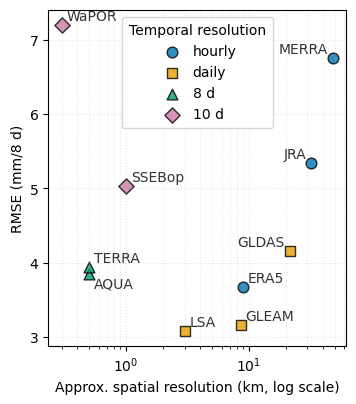

In [3]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

IRELAND_LAT_DEG = 53.5

lat = np.deg2rad(IRELAND_LAT_DEG)
lat_km = 111.13292 - 0.55982*np.cos(2*lat) + 0.001175*np.cos(4*lat) - 0.0000023*np.cos(6*lat)
lon_km = 111.41284*np.cos(lat) - 0.0935*np.cos(3*lat) + 0.000118*np.cos(5*lat)

angular_res_deg = {
    'MERRA': (0.5, 0.625),
    'JRA': 0.375,
    'GLDAS': 0.25,
    'GLEAM': 0.1
}
nominal_res_km = {
    'ERA5': 9.0,
    'LSA': 3.0,
    'SSEBop': 1.0,
    'AQUA': 0.5,
    'TERRA': 0.5,
    'WaPOR': 0.3
}

def resolution_km(product):
    if product in nominal_res_km:
        return nominal_res_km[product]
    res = angular_res_deg[product]
    dlat, dlon = res if isinstance(res, tuple) else (res, res)
    return float(np.sqrt(dlat * lat_km * dlon * lon_km)) 

df = pd.DataFrame({
    'Product': ['MERRA', 'JRA', 'GLDAS', 'GLEAM', 'ERA5', 'LSA', 'SSEBop', 'AQUA', 'TERRA', 'WaPOR'],
    'Temporal_Resolution': ['hourly', 'hourly', 'daily', 'daily', 'hourly', 'daily',
                            '10 d', '8 d', '8 d', '10 d']
})
df['Resolution_km'] = df['Product'].map(resolution_km)

R_RMSEm = xr.open_dataarray('../DATA/STN_RMSE.nc').drop_sel(Product=['PM', 'TH']).mean(dim='Station')
df['RMSE'] = R_RMSEm.sel(Product=df['Product'].tolist()).to_numpy()

plt.rcParams.update({
    'font.size': 10, 'axes.labelsize': 10, 'xtick.labelsize': 10,
    'ytick.labelsize': 10, 'legend.fontsize': 10, 'legend.title_fontsize': 10
})
fig, ax = plt.subplots(figsize=(3.5, 4))
style_dict = {
    'hourly': {'color': '#0072B2', 'marker': 'o'},
    'daily': {'color': '#E69F00', 'marker': 's'},
    '8 d': {'color': '#009E73', 'marker': '^'},
    '10 d': {'color': '#CC79A7', 'marker': 'D'}
}

for temp_res, style in style_dict.items():
    subset = df[df['Temporal_Resolution'] == temp_res]
    ax.scatter(subset['Resolution_km'], subset['RMSE'], c=style['color'],
               s=60, edgecolor='k', marker=style['marker'], label=temp_res, alpha=0.8)

ax.set_xscale('log')
xmin, xmax = ax.get_xlim()
threshold = 10 ** (np.log10(xmin) + 0.75*(np.log10(xmax) - np.log10(xmin)))

for _, row in df.iterrows():
    x, y = row['Resolution_km'], row['RMSE']
    place_left = row['Product'] == 'MERRA' or x > threshold
    dy = -10 if row['Product'] == 'AQUA' else 3.5
    ax.annotate(row['Product'], (x, y), xytext=((-3.5 if place_left else 3.5), dy),
                textcoords='offset points', fontsize=10, alpha=0.8,
                ha=('right' if place_left else 'left'))   

ax.set_xlabel('Approx. spatial resolution (km, log scale)')
ax.set_ylabel('RMSE (mm/8 d)')
ax.grid(True, which='both', ls=':', alpha=0.3)
ax.legend(title='Temporal resolution', frameon=True, framealpha=0.8,
          loc='upper center', borderpad=0.5, handletextpad=0.5)
fig.tight_layout(pad=0.5)
fig.savefig('ET4I_Resolution.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()
